In [26]:
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6

import numpy as np
import matplotlib.pyplot as plt

import sys

#from ham_creation import create_hex_ham
from lat_creation import get_positions_graphene
from core import DOS_sparse, frequency_analysis, load_data, load_data_dict, frequency_analysis_dict
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# Benchmarking
from time import time
from datetime import timedelta

hbar = 0.6582
a_l = 0.24595
a_cc = a_l/3**0.5


M = 0.0
t = 2.7
vf  = 3*a_cc*abs(t)/(2*hbar)

# Matplotlib stuff
plt.rcParams.update({'font.size': 11})  # Match REVTeX default 10pt
plt.rcParams['pdf.fonttype'] = 42  # Save text as TrueType (editable) instead of paths
plt.rcParams['ps.fonttype'] = 42   # Same for PostScript
plt.rcParams['text.usetex'] = True  # Keep LaTeX rendering
plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams.update({
    'font.size': 11,              # Tamaño base general (afecta a textos libres)
    'figure.titlesize': 18,       # Título principal de la figura (suptitle)
    'axes.titlesize': 12,         # Título de cada gráfico (title)
    'axes.labelsize': 12,         # Etiquetas de los ejes (xlabel e ylabel)
    'xtick.labelsize': 11,        # Números/marcas del eje X
    'ytick.labelsize': 11,        # Números/marcas del eje Y
    'legend.fontsize': 11,        # Texto de los elementos de la leyenda
    'legend.title_fontsize': 11   # Título de la leyenda
})

# Configuración exclusiva para grosores y tamaños de elementos visuales
plt.rcParams.update({
    # 1. Líneas y Marcadores (El contenido de tus gráficos)
    'lines.linewidth': 3,          # Grosor de las líneas de los gráficos
    'lines.markersize': 10,           # Tamaño de los puntos/marcadores
    'lines.markeredgewidth': 1.5,    # Grosor del borde de los marcadores

    # 2. Gráficos de barras y formas (Patches)
    #'patch.linewidth': 1.2,          # Grosor del borde de las barras (plt.bar) o rectángulos

    # 3. El marco del gráfico (Ejes / Spines)
    #'axes.linewidth': 1.5,           # Grosor de la línea del recuadro exterior del gráfico

    # 4. La cuadrícula (Grid)
    'grid.linewidth': 0.8,           # Grosor de las líneas de la cuadrícula de fondo

    # 5. Las pequeñas marcas de los ejes (Ticks)
    'xtick.major.size': 6,           # Qué tan largas son las marcas del eje X
    'xtick.major.width': 1.5,        # Qué tan gordas son las marcas del eje X
    'ytick.major.size': 6,           # Qué tan largas son las marcas del eje Y
    'ytick.major.width': 1.5         # Qué tan gordas son las marcas del eje Y
})


In [27]:
# ------------------------------------------------------------------------------
#### PARAMETERS OF THE MODEL
out_file_loc = ''
## PHYSICAL
modifier_id = 'circln'
# Parameters of the ham (only read if hbn)
ham_params = 0.5
# Energy in pulse                        
E = 1.0
# Temperature                       
Temp = 1e-9
# Chemical potential
mu = 0.01
# Intensity param     (no units)
gamma_list = np.linspace(0.000, 0.025, 6)                   

## SIMULATION
# Size of hamiltonian
N_pot = 20
N = 2**N_pot
# Amount of periods to be simulated
n_periods = 500
# Simulation steps per period
steps_per_T = 1000
# Amount of measures per period
meas_per_T = 16
# Amount of random vectors used in calculation
N_random_vector = 5
# Momenta
M = int(np.sqrt(N))


## RESULT ANALYSIS
hE_reps = 2
res1 = {'modifier_id': modifier_id,
        'type_ham': 'basic',
        'ham_params': ham_params,  
        'hw' : E,                       
        'Temp' :  Temp,
        'mu' : mu,                 
        'N_pot' : N_pot,
        'steps_per_T' : steps_per_T,
        'n_periods' : n_periods,
        'meas_per_T' : meas_per_T,
        'N_random_vector' : 5,
        'M' : int(np.sqrt(2**N_pot)),
        'label': 'circular graphene',
        'color1': 'blue',
        'color2': 'cyan',
        'ls' : 'dashed'}


res2 = res1.copy()
res2['type_ham'] = 'hbn'
res2['label'] = 'circular hbn'


list_res = [res1, res2]
for res in list_res:
    res['char_freq'] = np.zeros((len(gamma_list), 2*hE_reps+1))
    res['w'] = res['hw']/hbar 
    res['T'] = 2*np.pi/res['w'] 


5/5 calculations finished! Loading 5 results...
5/5 calculations finished! Loading 5 results...
4/5 calculations finished! Loading 4 results...
1/5 calculations finished! Loading 1 results...
5/5 calculations finished! Loading 5 results...
2/5 calculations finished! Loading 2 results...
5/5 calculations finished! Loading 5 results...
3/5 calculations finished! Loading 3 results...
5/5 calculations finished! Loading 5 results...
4/5 calculations finished! Loading 4 results...
5/5 calculations finished! Loading 5 results...
4/5 calculations finished! Loading 4 results...


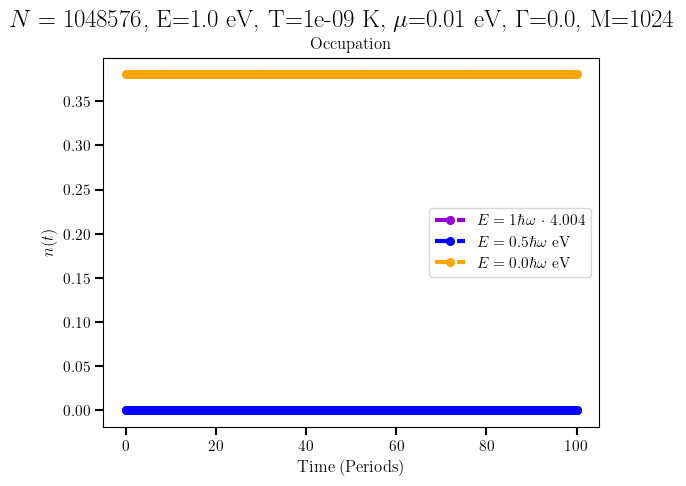

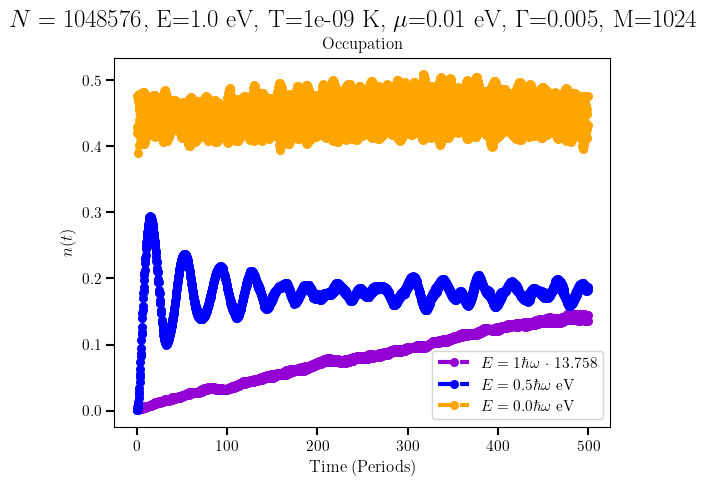

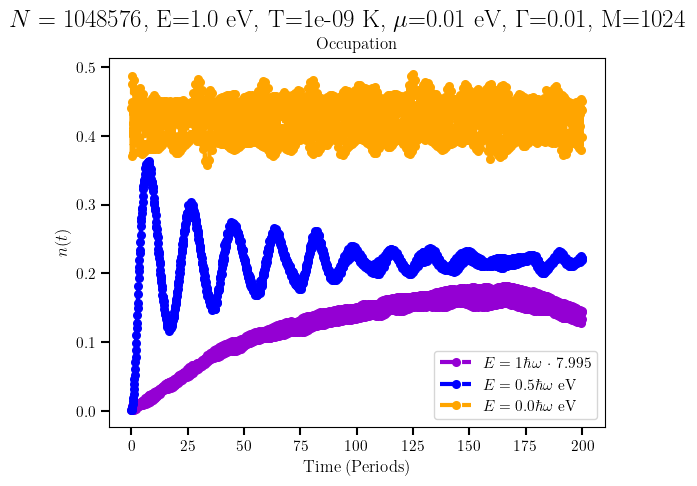

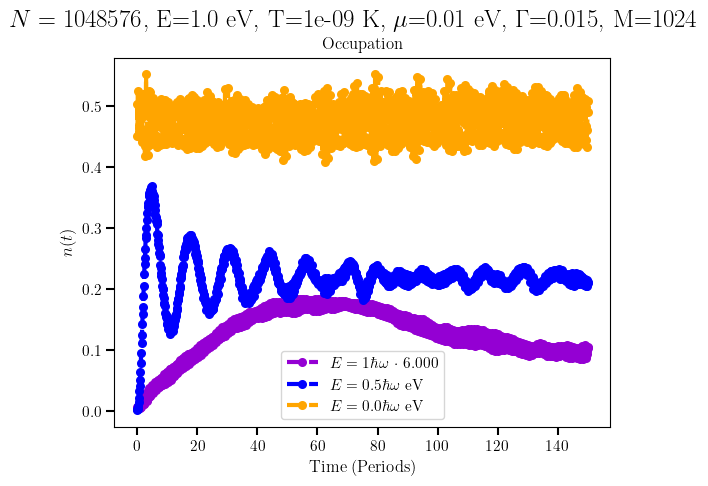

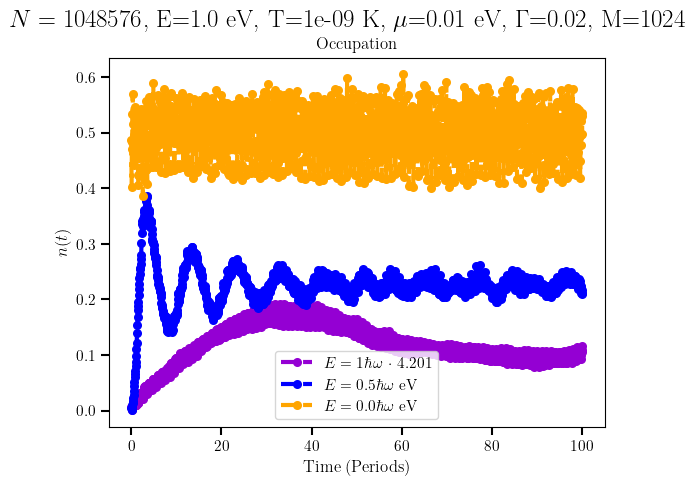

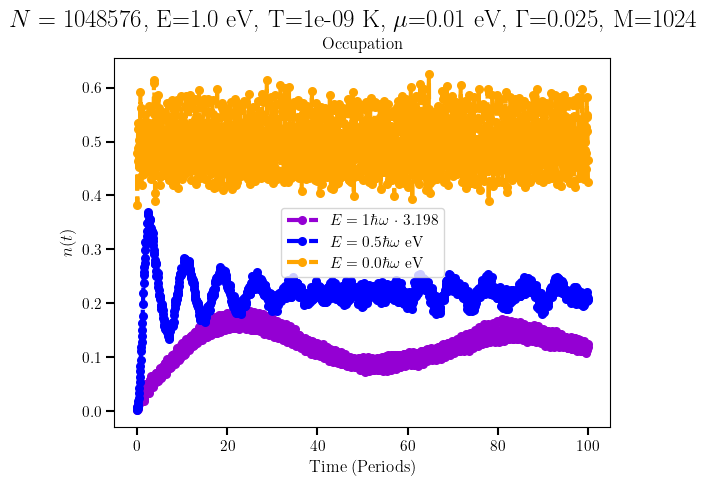

In [28]:
## RESULT ANALYSIS
## CALCULATED PARAMS

timeframe_intensity_list = [(0.000, 100, 4, 1.0),
                            (0.005, 500, 4, 1.0),
                            (0.010, 200, 8, 1.0),
                            (0.015, 150, 8, 1.0),
                            (0.020, 100, 16, 1.0),
                            (0.025, 100, 16, 1.0),
                            (0.030, 80, 24, 1.0),
                            (0.035, 80, 24, 1.0),
                            (0.040, 50, 32, 1.0),
                            (0.045, 50, 32, 1.0),
                            (0.050, 50, 32, 1.0)]

for (g, gamma) in enumerate(gamma_list):
    if M == 0:
        M = int(np.sqrt(N))
    for res in list_res:
        res['gamma'] = gamma
        res['n_periods'], res['meas_per_T'], res['hw'] = timeframe_intensity_list[g][1:]
        res['t_vec'] = np.linspace(0,res['n_periods']*res['T'] , res['steps_per_T']*res['n_periods'])   
        res['t_vec_measures'] = np.linspace(0, res['n_periods']*res['T'], res['meas_per_T']*res['n_periods'])
        load_data_dict(res)
        frequency_analysis_dict(res, use_dosn=False)
        res['char_freq'][g] = res['char_freq_s']

    
    color_list = ['olivedrab', 'red', 'orange', 'blue', 'darkviolet']
    # Names of file and info on graphs
    fig_title_info = f'$N={{{2**N_pot}}}$, E={E} eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}, M={M}'

    # --------------------------------------------------------------------------
    # OCCUPATION(time) GRAPH
    # General figure to contain all important data
    res = list_res[0]
    fig, ax = plt.subplots()
    reescale = np.max(res['occ_drop_list'][3]) / np.max(res['occ_drop_list'][4]) / 2
    ax.plot(res['t_vec_measures']/res['T'], res['occ_drop_list'][4]*reescale, c='darkviolet', 
            marker='.', ls='--', label=f"$E=1\\hbar\\omega$ $\\cdot$ {reescale:.3f}")
    ax.plot(res['t_vec_measures']/res['T'], res['occ_drop_list'][3], c='blue', 
            marker='.', ls='--', label=f"$E=0.5\\hbar\\omega$ eV")
    ax.plot(res['t_vec_measures']/res['T'], res['occ_drop_list'][2], c='orange', 
            marker='.', ls='--', label=f"$E=0.0\\hbar\\omega$ eV")
    ax.set_xlabel('Time (Periods)')
    ax.set_ylabel('$n(t)$')
    ax.set_title(fr'Occupation')
    fig.suptitle(fig_title_info)
    ax.legend()

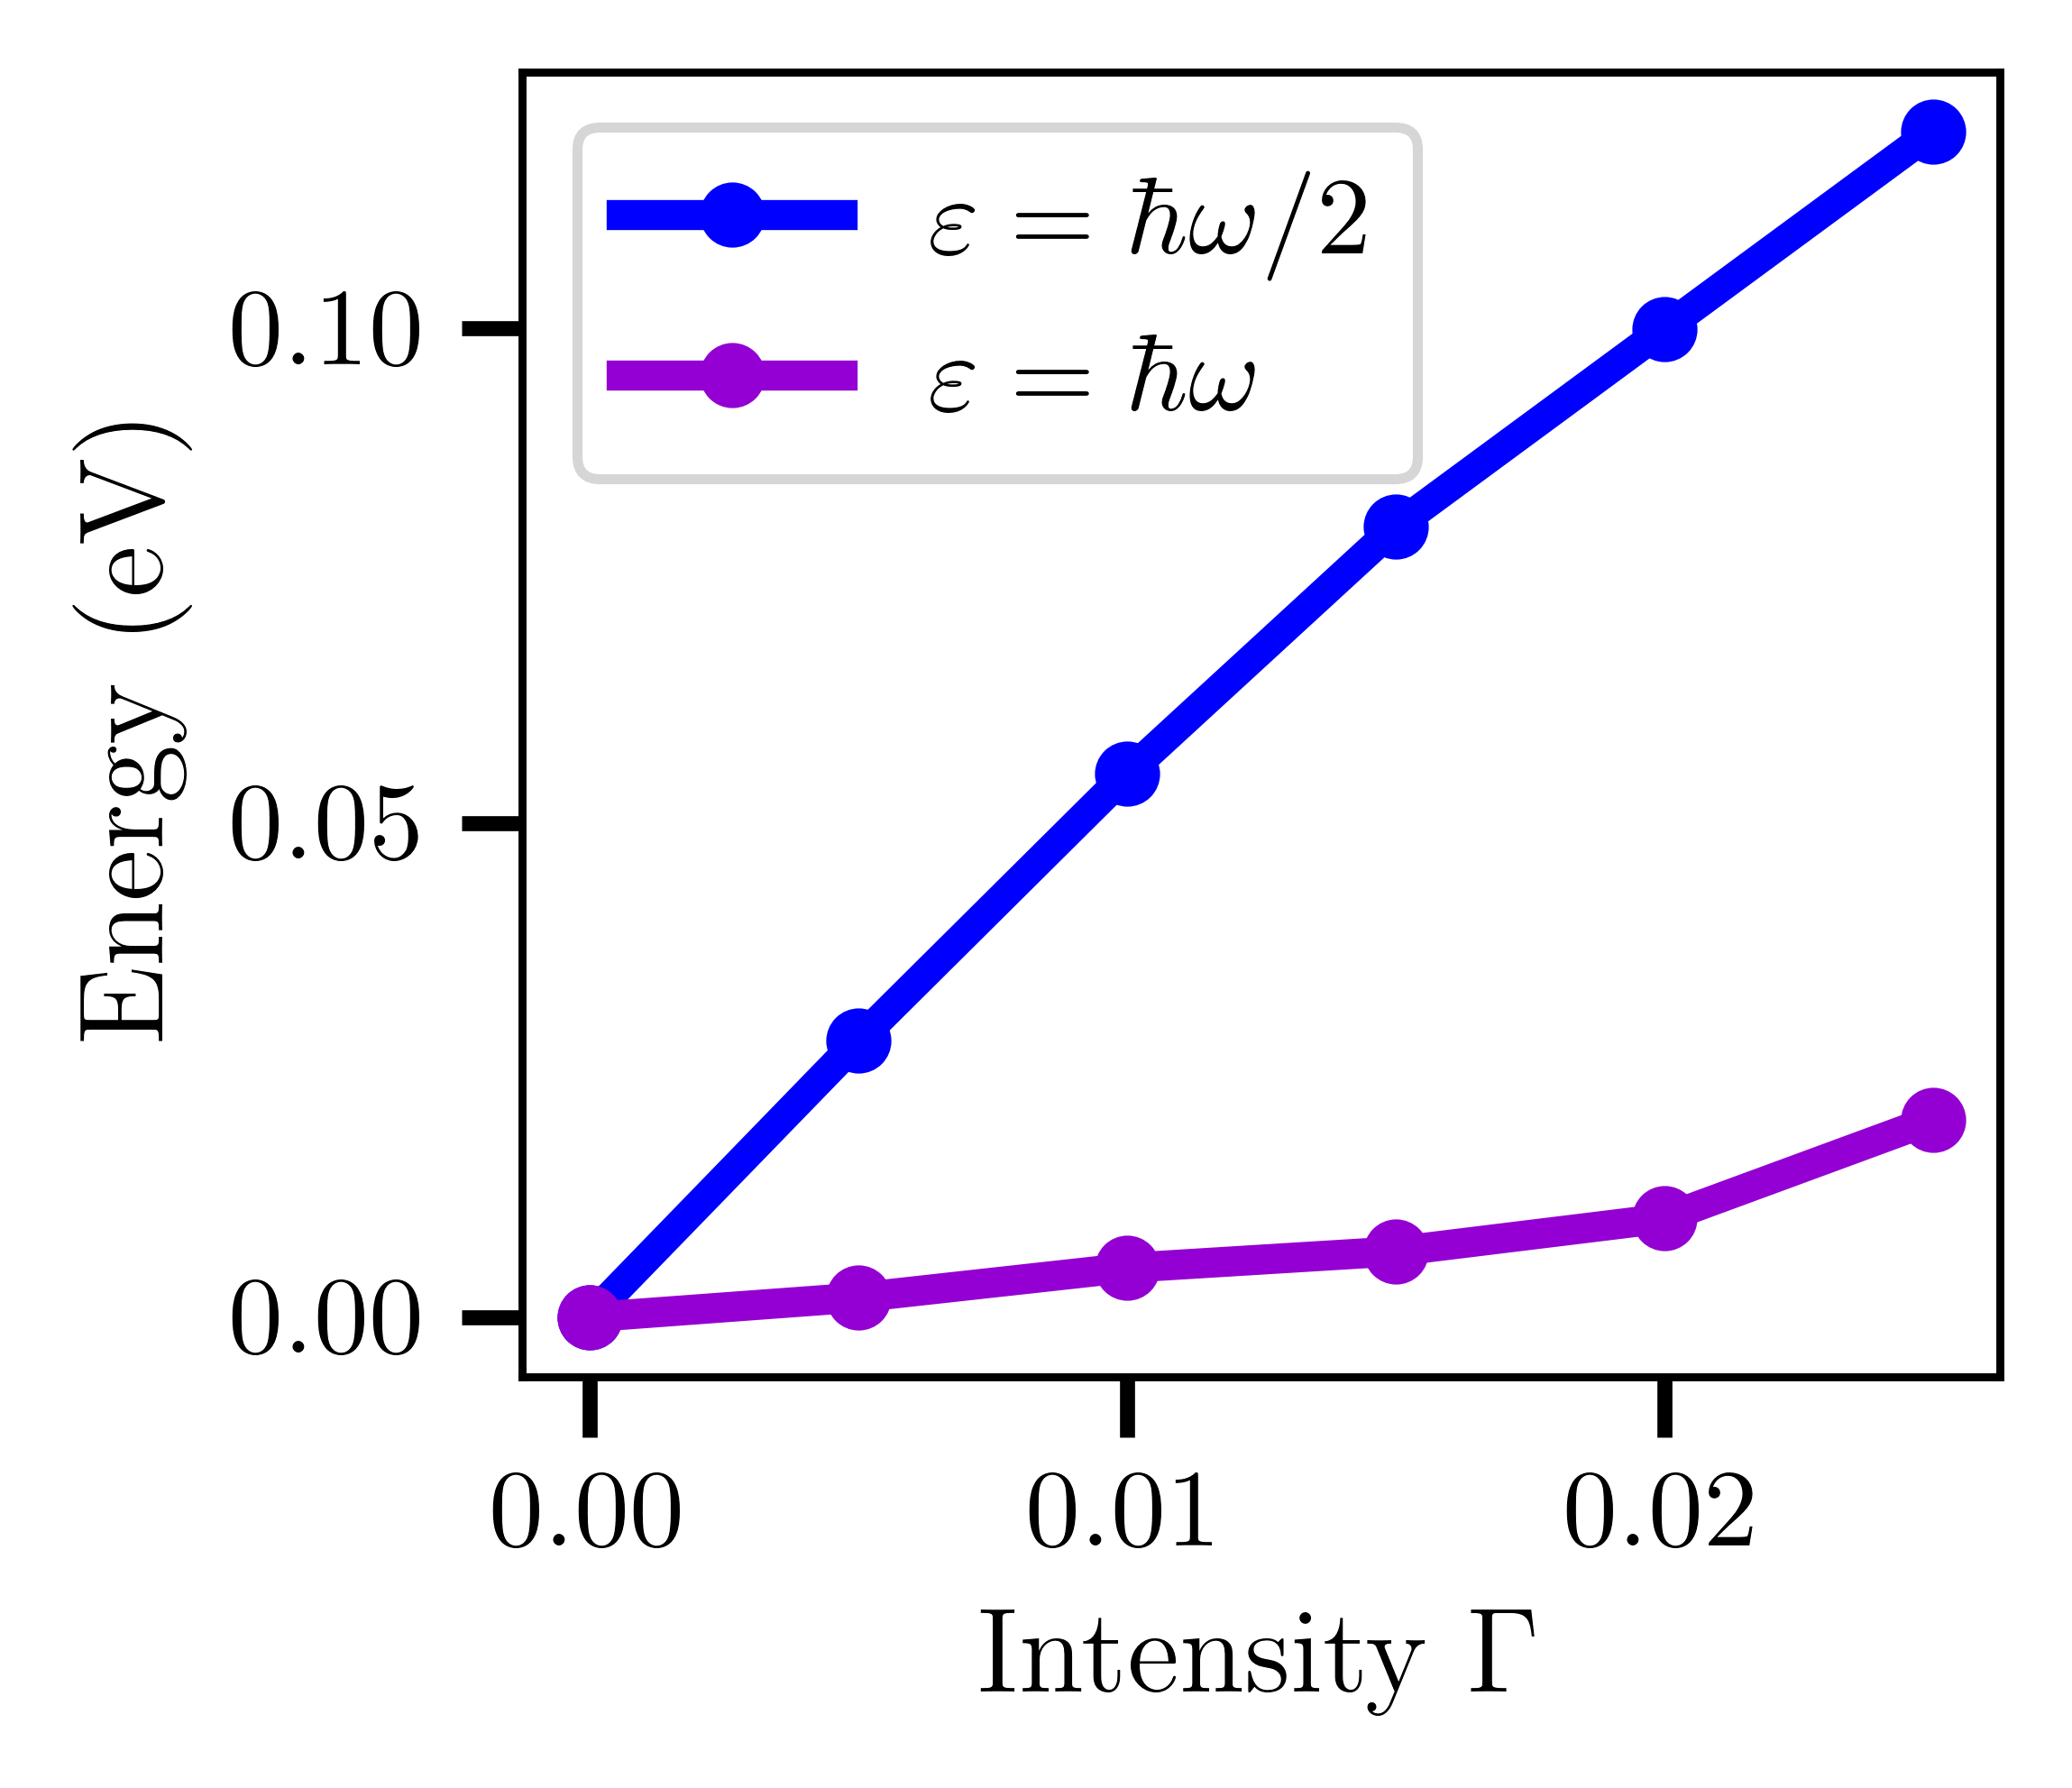

In [29]:
res = list_res[0]

# Final plot of the gammas
fig, ax = plt.subplots(dpi=800, figsize=(7/2.54, 6/2.54), layout='constrained')
#ax.plot(gamma_list, char_freq[:,2], ls='--', c=color_list[2], marker='.',
#        label=f'$E = \\mu$ eV')
ax.plot(gamma_list, res['char_freq'][:,3]*hbar, ls='-', c='blue', marker='.', label=f'$\\varepsilon = \\hbar\\omega/2$')
ax.plot(gamma_list, res['char_freq'][:,4]*hbar, ls='-', c='darkviolet', marker='.', label=f'$\\varepsilon =\\hbar\\omega$')
ax.set_xlabel(f'Intensity $\\Gamma$')
ax.set_ylabel('Energy (eV)')
ax.legend()
#ax.set_xticks(gamma_list)
#fig.suptitle(f'$N={{{2**N_pot}}}$, $\\hbar\\omega$={E} eV, Temp={Temp} K, $\\mu$={mu} eV')
fig.savefig('Graphs/neq_freqs.pdf')

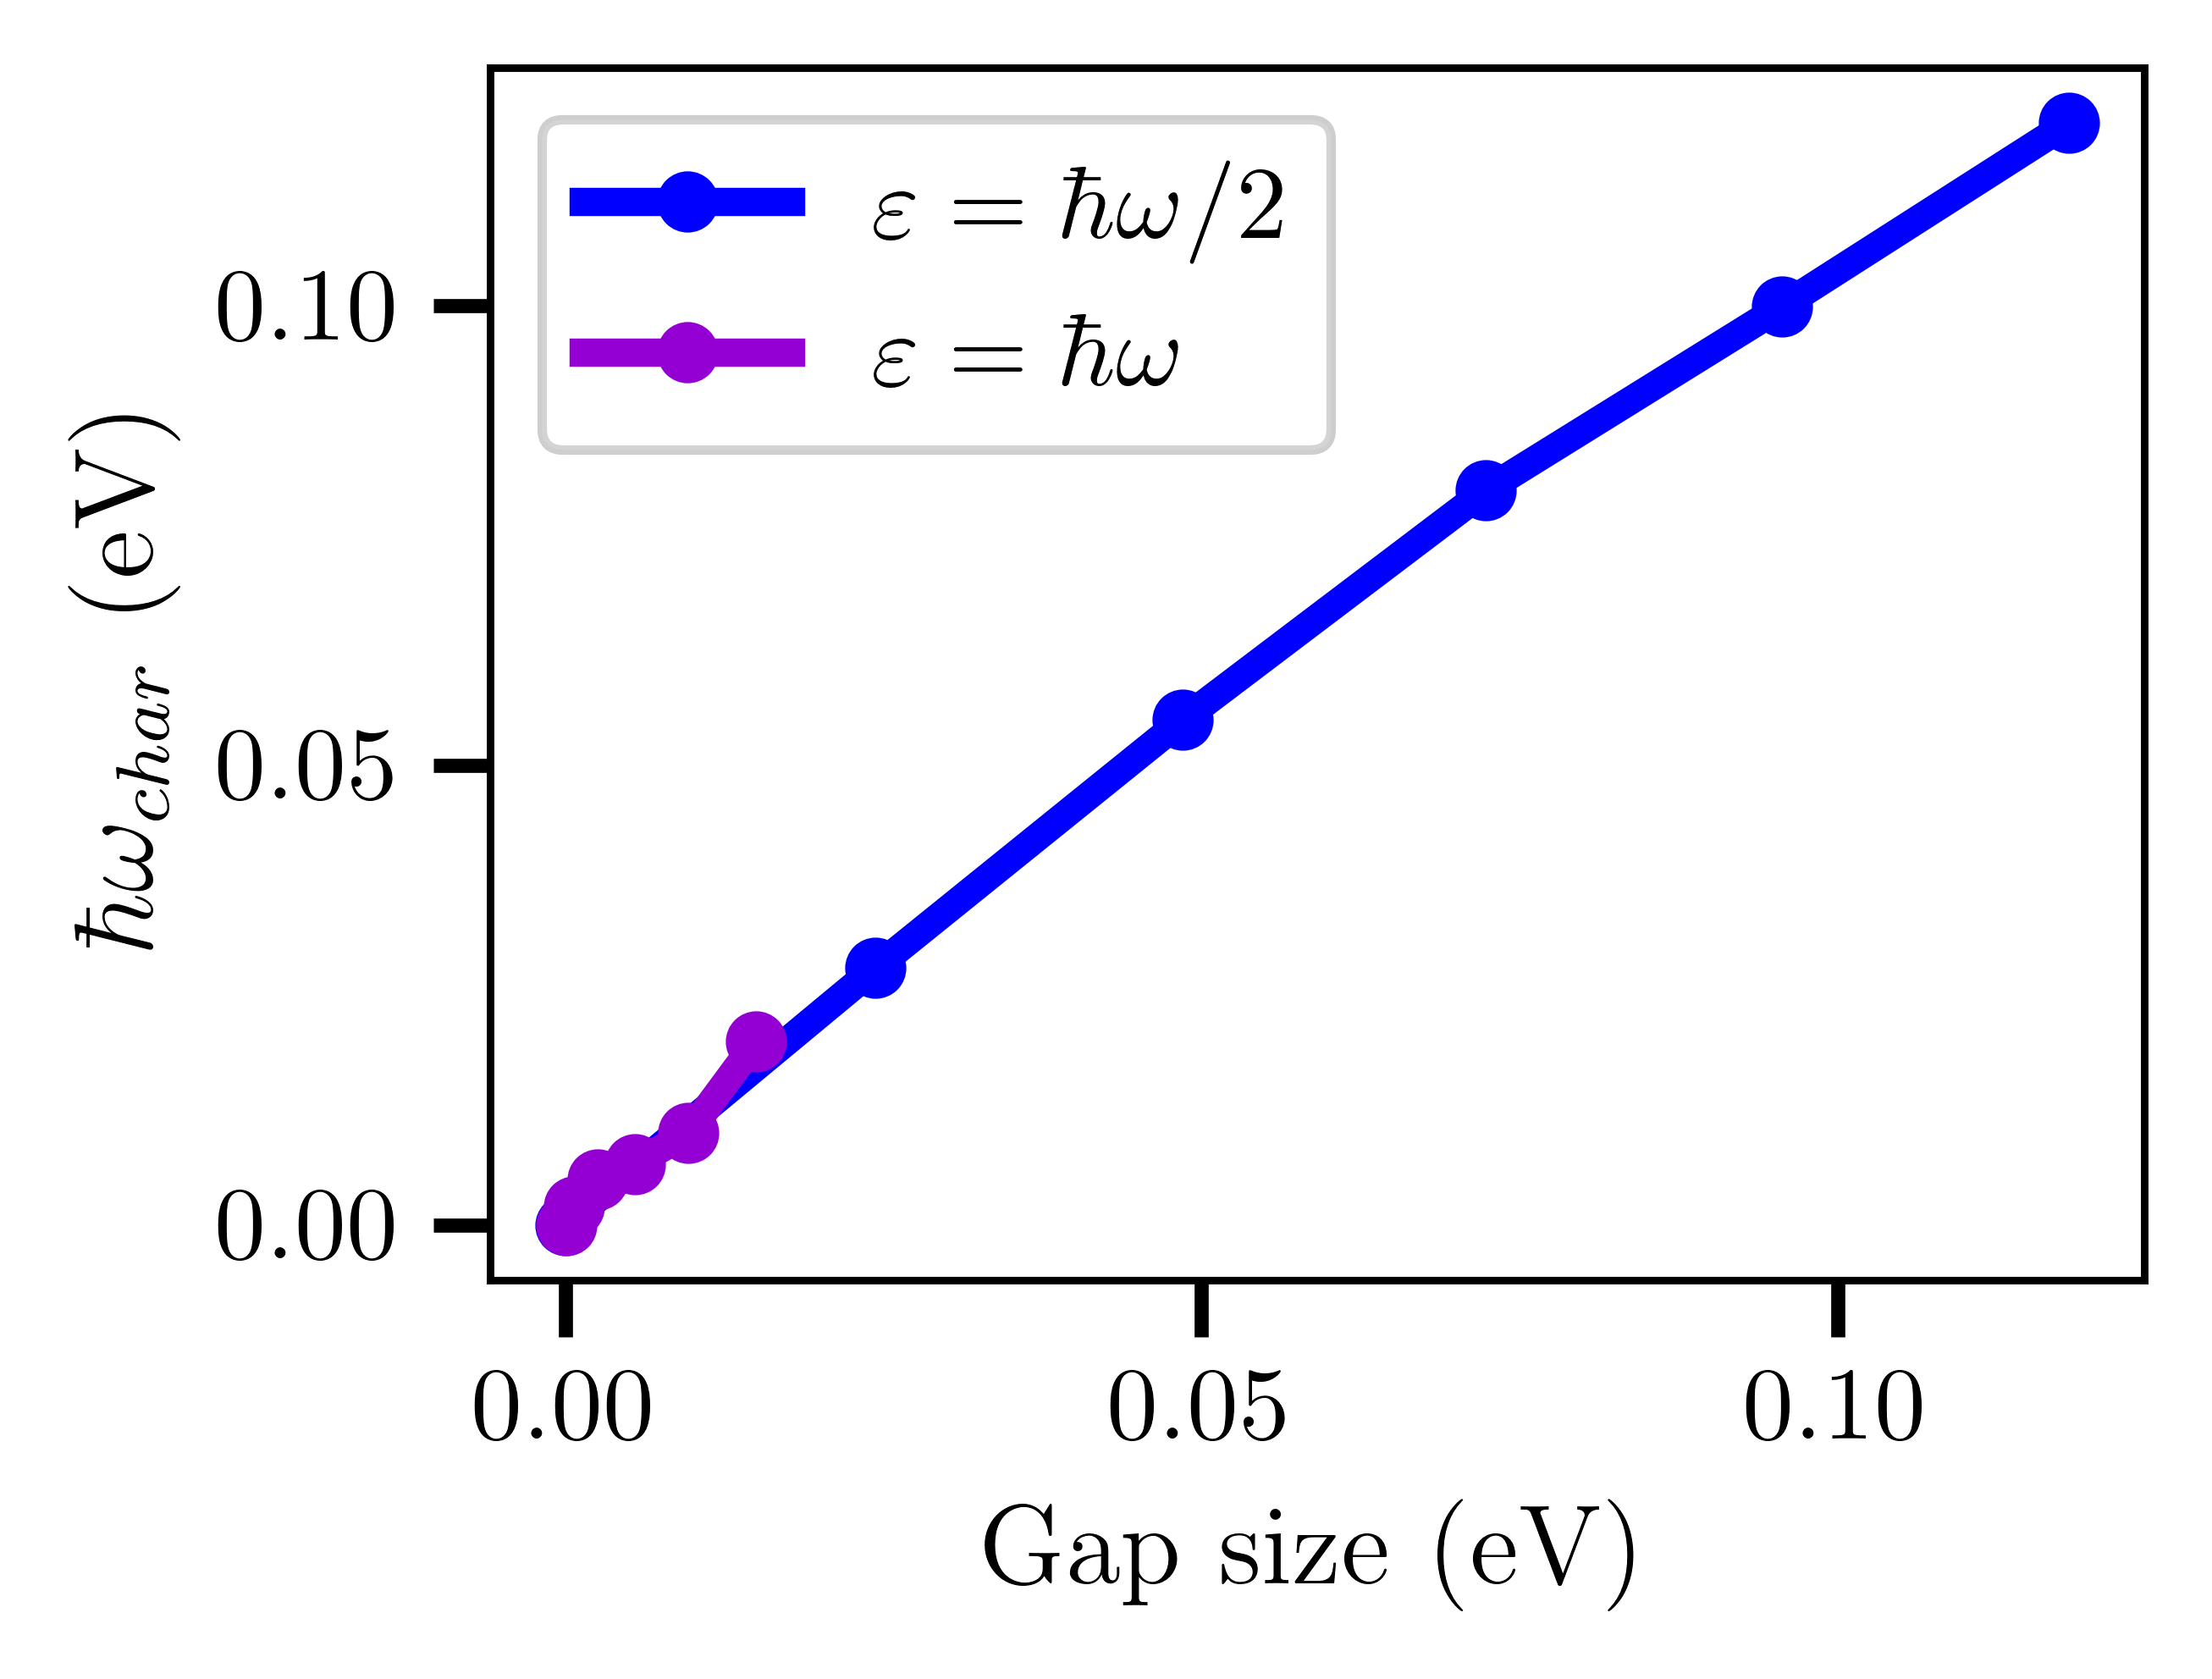

In [40]:

#%% Fitting to see if a relation is even possible
# Importing the results from Floquet
n_rep = 4
gamma_fl_og = np.load(f'band_gaps/{res['modifier_id']}_real/hw={E}_nrep={n_rep}/gamma_fl.npy')
gap0_fl_og = np.load(f'band_gaps/{res['modifier_id']}_real/hw={E}_nrep={n_rep}/gap0.npy')
gap1_fl_og = np.load(f'band_gaps/{res['modifier_id']}_real/hw={E}_nrep={n_rep}/gap1.npy')
gap2_fl_og = np.load(f'band_gaps/{res['modifier_id']}_real/hw={E}_nrep={n_rep}/gap2.npy')


char_freq = res1['char_freq']
# Seeing which indexes are used in the other results
used_inds = []
for (i, g_fl) in enumerate(gamma_fl_og):
    if g_fl in gamma_list:
        used_inds.append(i)

# Applying the results
gamma_fl = gamma_fl_og[used_inds]
gap0_fl = gap0_fl_og[used_inds]
gap1_fl = gap1_fl_og[used_inds]
gap2_fl = gap2_fl_og[used_inds]

# Fitting of the curve
from scipy.stats import linregress
# GAP1 REGRESSION
lin_reg1 = linregress(gap1_fl, char_freq[:,3]*hbar)
slope1 = lin_reg1.slope
intercept1 = lin_reg1.intercept
R2_1 = lin_reg1.rvalue**2
test_gaps1 = np.linspace(np.min(gap1_fl), np.max(gap1_fl), 100)
lin_predict1 = slope1*test_gaps1 + intercept1

# GAP2 REGRESSION
lin_reg2 = linregress(gap2_fl, char_freq[:,4]*hbar)
slope2 = lin_reg2.slope
intercept2 = lin_reg2.intercept
R2_2 = lin_reg2.rvalue**2
test_gaps2 = np.linspace(np.min(gap2_fl), np.max(gap2_fl), 100)
lin_predict2 = slope2*test_gaps2 + intercept2

# Graph of the results
fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')

# IMPORTANTE: Nota la coma ',' después del nombre de la variable para desempaquetar la línea
site1, = ax.plot(gap1_fl, char_freq[:,3]*hbar, ls='-', marker='.', color='blue', label='$\\varepsilon = \\hbar \\omega / 2$')
#reg1, = ax.plot(test_gaps1, lin_predict1, color='cyan', ls='--', label=f'$y={slope1:.3f}x$')

site2, = ax.plot(gap2_fl, char_freq[:,4]*hbar, ls='-', marker='.', color='darkviolet', label='$\\varepsilon = \\hbar \\omega$')
#reg2, = ax.plot(test_gaps2, lin_predict2, color='red', ls='--', label=f'$y={slope2:.3f}x$')

ax.set_xlabel('Gap size (eV)')
ax.set_ylabel('$\\hbar \\omega_{char}$ (eV)')
#ax.set_title('Comparison Floquet vs NEQ')

# 1. Creamos la primera leyenda (Sitios) y la añadimos al eje
first_legend = ax.legend(handles=[site1, site2], loc='upper left')
ax.add_artist(first_legend)  # Esto evita que se borre al meter la segunda
fig.savefig('Graphs/neq_comparison.pdf')
# 2. Creamos la segunda leyenda (Regresiones)
#ax.legend(handles=[reg1, reg2], loc='lower right')

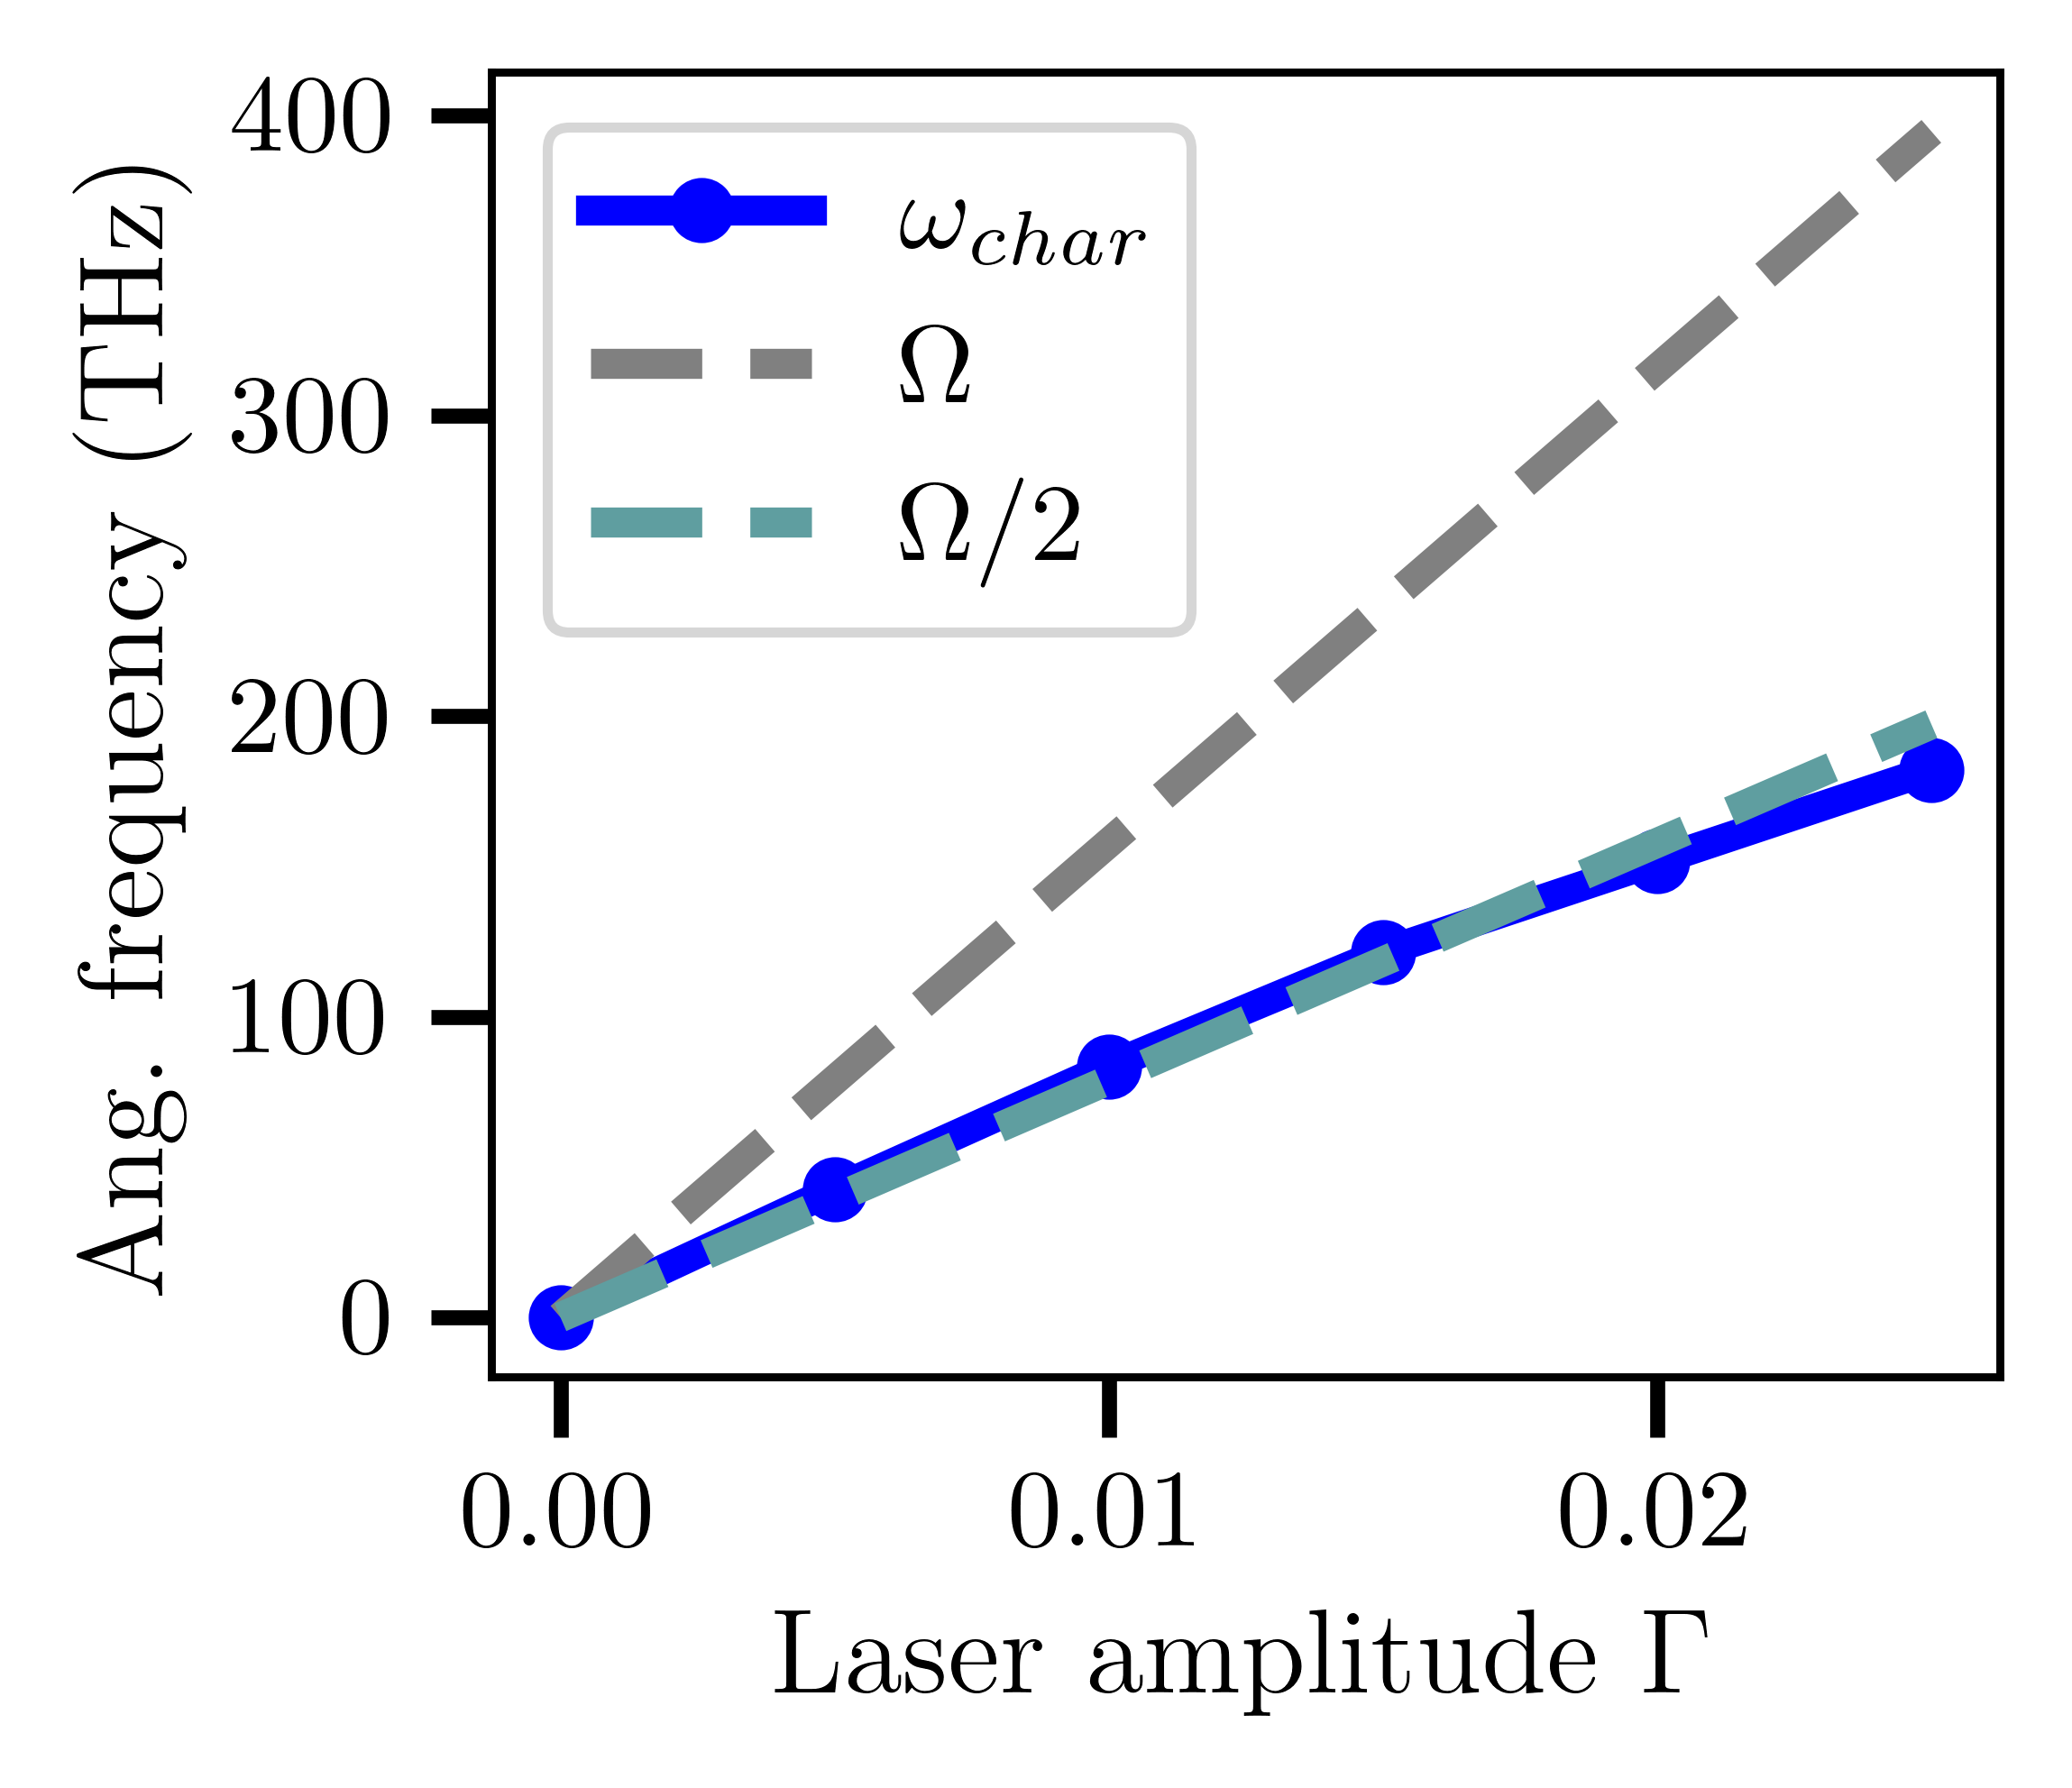

In [39]:
#%% Trying Rabi stuff to see if theoretical results make sense using gap


t = -2.7
Phi0 = 2*np.pi*hbar
if modifier_id == 'circln':
    w1 = np.sqrt(3)*t*gamma_list*np.pi/hbar/2**0.5
else:
     w1 = np.sqrt(3)*t*gamma_list*np.pi/hbar
#w1 = 2*vf*A0/hbar


rep = 1
delta_w = (1-rep)*res1['w']
#delta_w = w_laser - gap1_fl/jcl.hbar_fs
rabi_freq = np.sqrt(delta_w**2 + w1**2)
#rabi_freq = 2*vf*A0/jcl.hbar_fs*np.sqrt(1+E**2/(vf**2*A0**2))



fig, ax = plt.subplots(dpi=800, figsize=(7/2.54, 6/2.54), layout='constrained')
ax.plot(gamma_list, char_freq[:,3]*1000, ls='-', c=color_list[3], marker='.', label='$\\omega_{char}$')
ax.plot(gamma_list, rabi_freq*1000, ls='--', c='grey', label=f'$\\Omega$')
ax.plot(gamma_list, rabi_freq/2*1000, ls='--', c='cadetblue', label=f'$\\Omega/2$')
#ax.set_title('Characteristic Frequencies in $E=0.5\\hbar\\omega$')
ax.set_xlabel('Laser amplitude $\\Gamma$')
ax.set_ylabel('Ang. frequency (THz)')
ax.legend()

#np.save('Out/char_freqs.npy', char_freq[:,3])

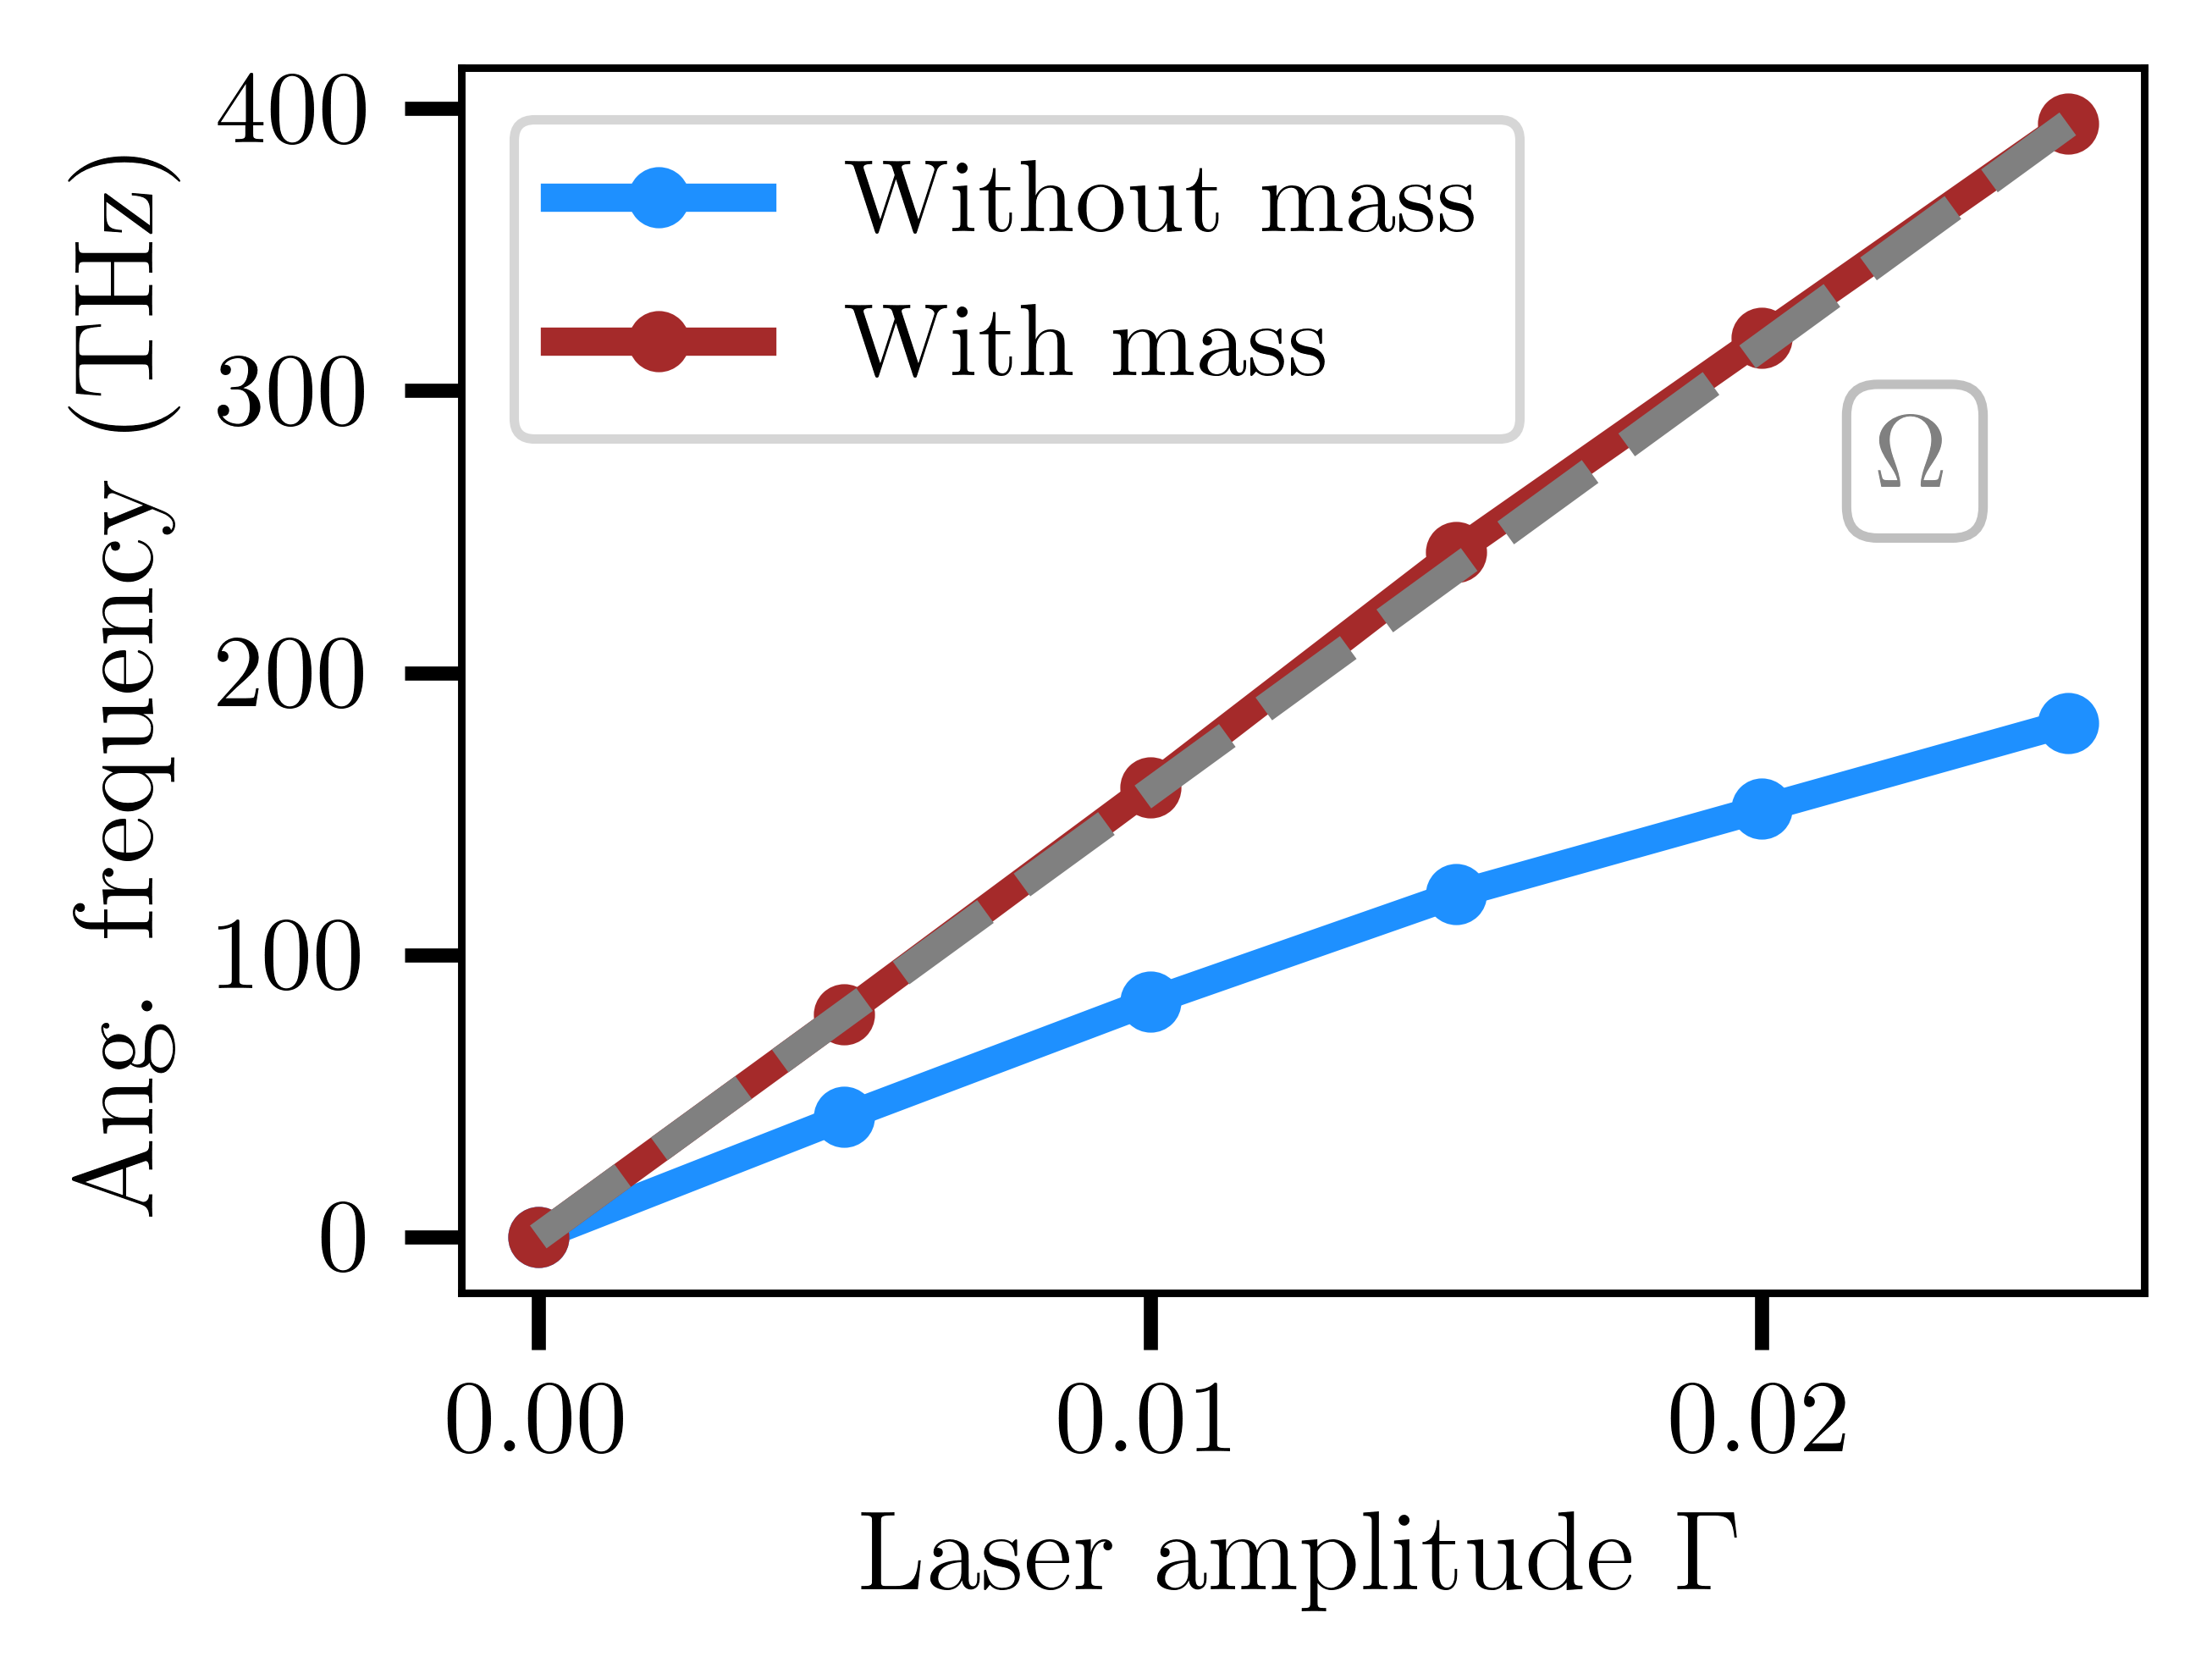

In [55]:
# Comparison between gapped graphene, usual graphene and Rabi
char_freq_hbn = res2['char_freq']
props = dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.5)

fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
ax.plot(gamma_list, char_freq[:,3]*1000, ls='-', c='dodgerblue', marker='.', label='Without mass')
ax.plot(gamma_list, char_freq_hbn[:,3]*1000, ls='-', marker='.', c='brown', label=f'With mass')
ax.plot(gamma_list, rabi_freq*1000, ls='--', c='grey')
ax.text(0.0225, 275, '$\\Omega$', color='grey', bbox=props, ha='center', va='center')
#ax.set_title('Characteristic Frequencies in $E=0.5\\hbar\\omega$')
ax.set_xlabel('Laser amplitude $\\Gamma$')
ax.set_ylabel('Ang. frequency (THz)')
ax.legend()
fig.savefig('Graphs/neq_mass.pdf')



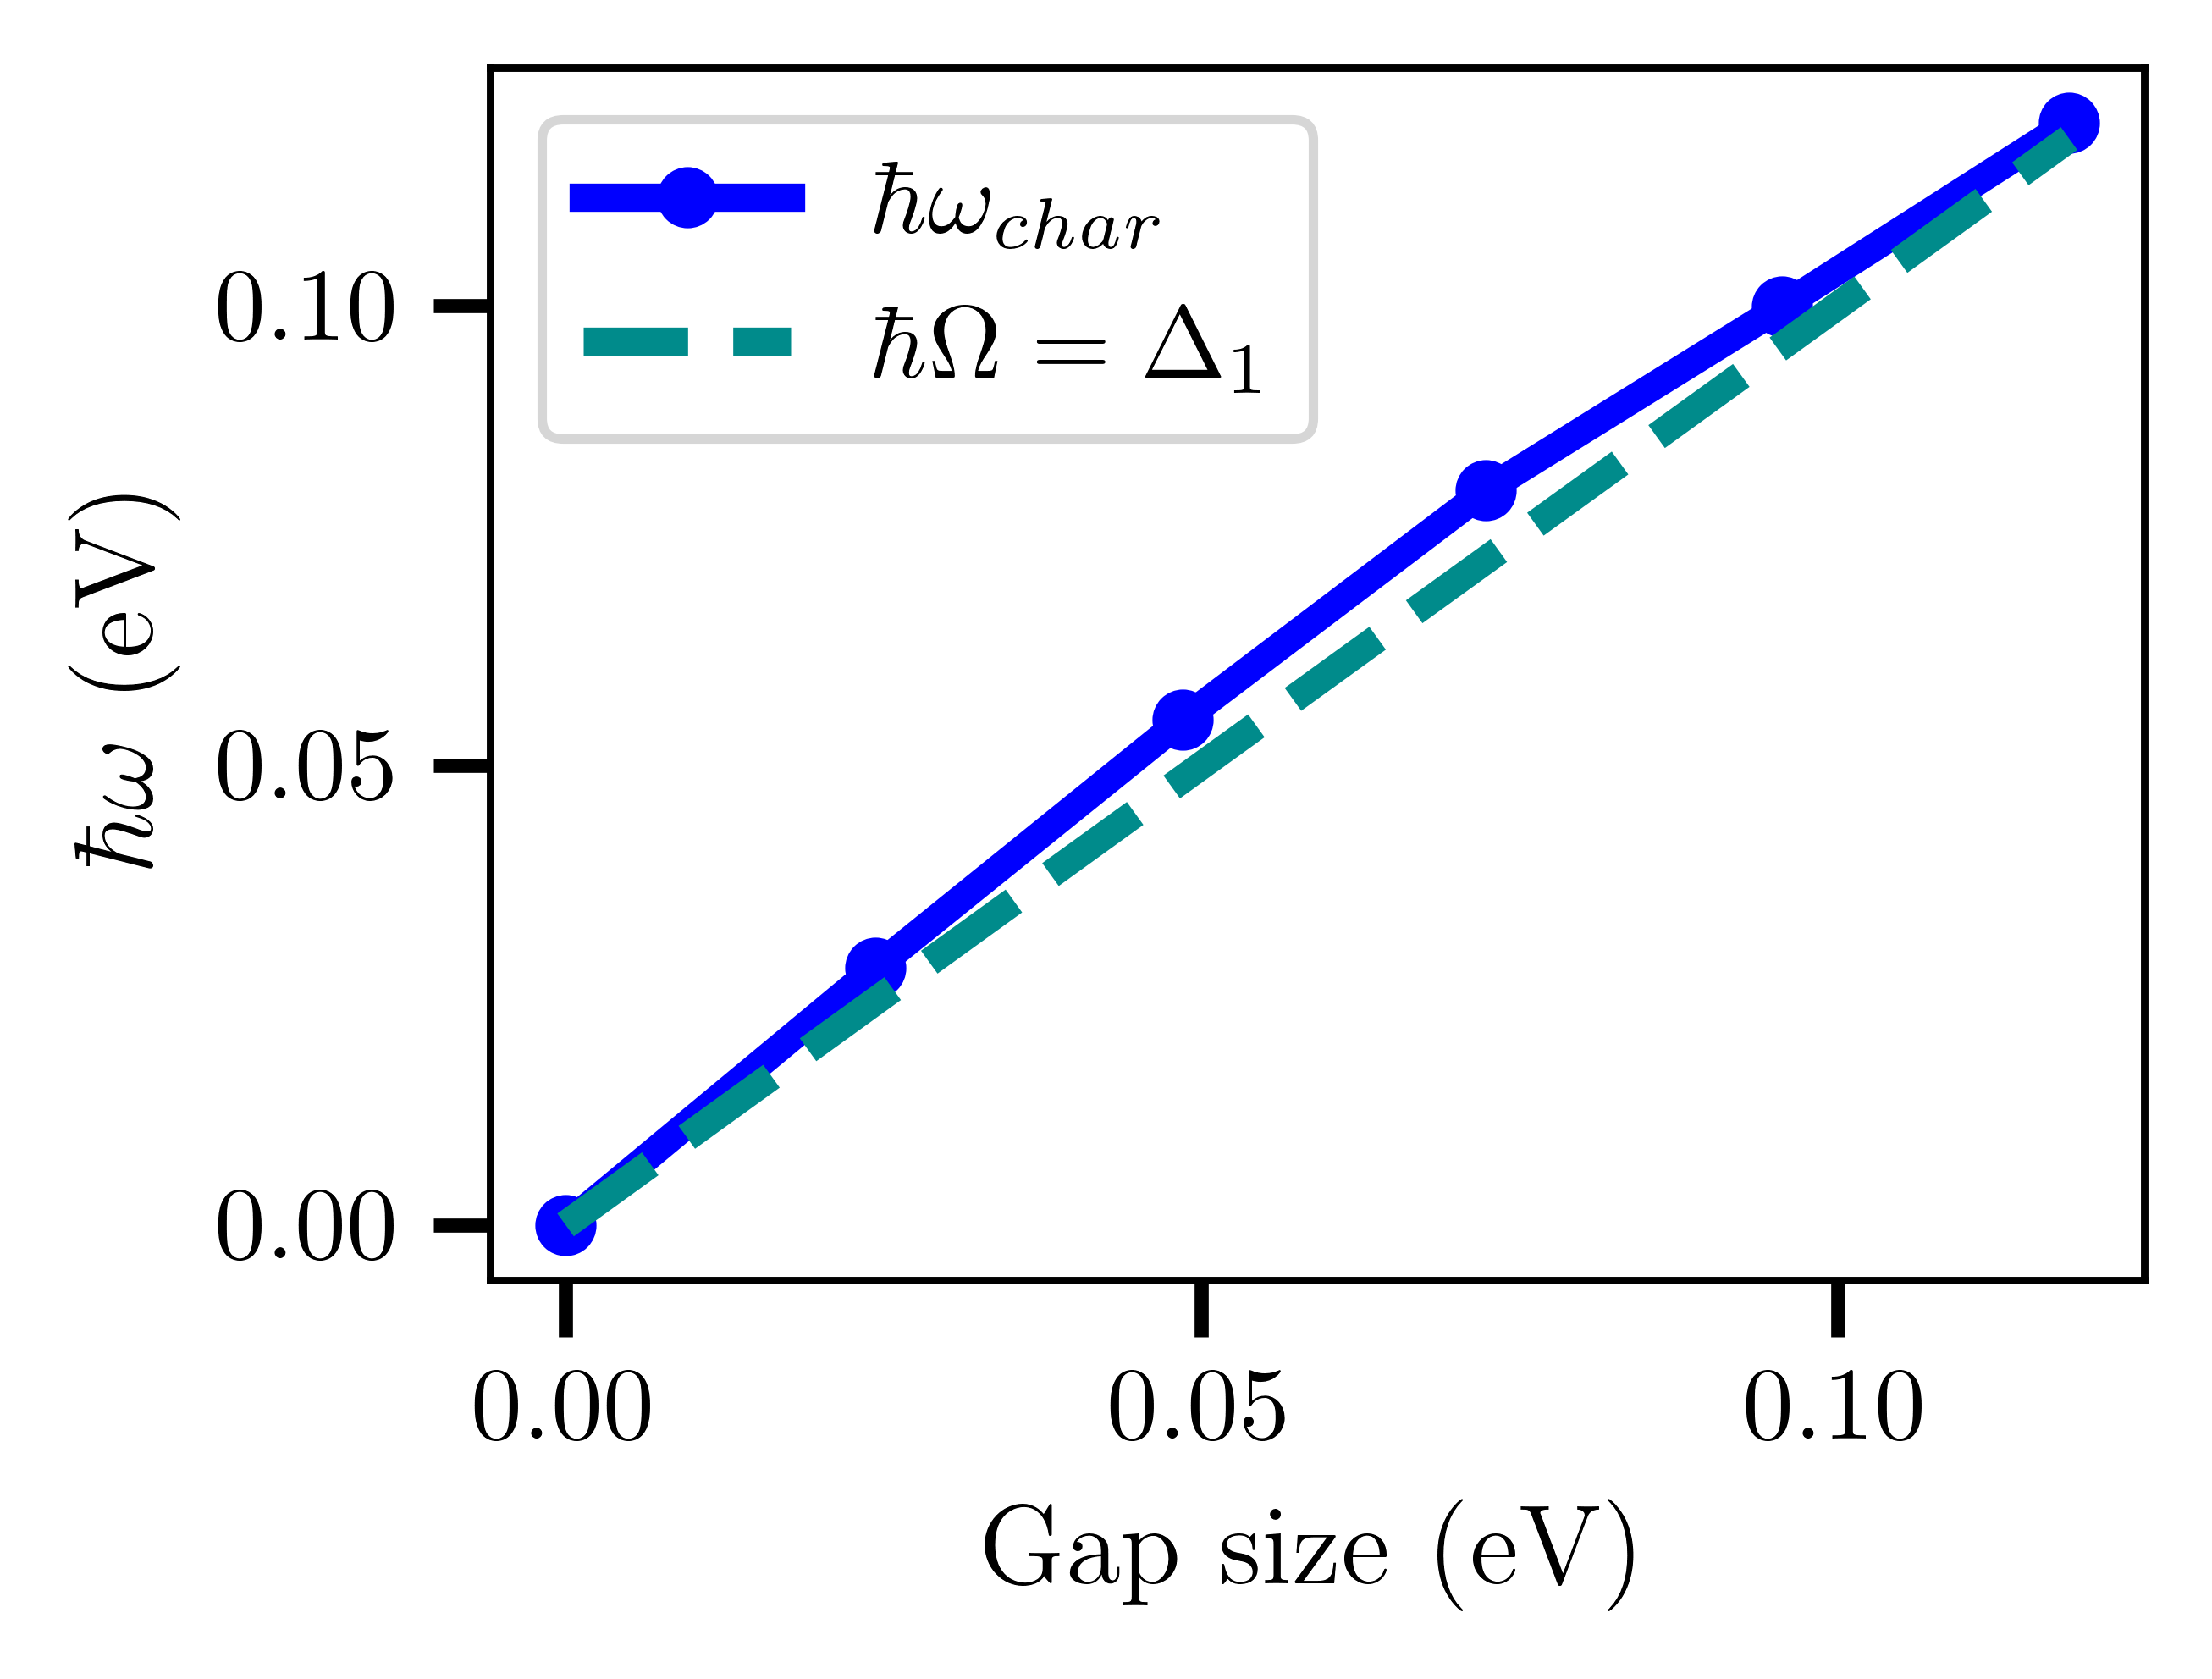

In [57]:
# Graph of the results
fig, ax = plt.subplots(dpi=800, figsize=(8/2.54, 6/2.54), layout='constrained')
# IMPORTANTE: Nota la coma ',' después del nombre de la variable para desempaquetar la línea
site1, = ax.plot(gap1_fl, char_freq[:,3]*hbar, ls='-', marker='.', color='blue', label='$\\hbar \\omega_{char}$')
site1, = ax.plot(gap1_fl_og, gap1_fl_og, ls='--', color='darkcyan', label='$\\hbar \\Omega = \\Delta_1$')
#reg1, = ax.plot(test_gaps1, lin_predict1, color='cyan', ls='--', label=f'$y={slope1:.3f}x$')

#reg2, = ax.plot(test_gaps2, lin_predict2, color='red', ls='--', label=f'$y={slope2:.3f}x$')
ax.set_xlabel('Gap size (eV)')
ax.set_ylabel('$\\hbar \\omega$ (eV)')
#ax.set_title('Comparison Floquet vs NEQ')

# 1. Creamos la primera leyenda (Sitios) y la añadimos al eje
ax.legend()
fig.savefig('Graphs/neq_formula_to_real.pdf')
# 2. Creamos la segunda leyenda (Regresiones)
#ax.legend(handles=[reg1, reg2], loc='lower right')